<a href="https://colab.research.google.com/github/CassioLima09/NLP_with_Transformers/blob/main/08_model-compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run this cell if you're on Colab or Kaggle
!git clone https://github.com/nlp-with-transformers/notebooks.git
%cd notebooks
from install import *
install_requirements()

Cloning into 'notebooks'...
remote: Enumerating objects: 530, done.
remote: Counting objects: 100% (209/209), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 530 (delta 184), reused 162 (delta 162), pack-reused 321 (from 2)
Receiving objects: 100% (530/530), 28.52 MiB | 16.58 MiB/s, done.
Resolving deltas: 100% (253/253), done.
/content/notebooks
⏳ Installing base requirements ...
✅ Base requirements installed!
⏳ Installing Git LFS ...
✅ Git LFS installed!


##OBJETIVOS
we’ll use intent detection as a case study; this is an important component of textbased assistants, where low latencies are critical for maintaining a conversation in real time.

Let’s suppose that we’re trying to build a text-based assistant for our company’s call center so that customers can request their account balance or make bookings without needing to speak with a human agent

our assistant will need to be able to classify a wide variety of natural language text into a set of predefined actions or intents.

In [ ]:
# hide
from utils import *
setup_chapter()

Using transformers v4.16.2
Using datasets v1.16.1


# Making Transformers Efficient in Production

<img alt="Scaling BERT at Roblox" caption="How Roblox scaled BERT with knowledge distillation, dynamic padding, and weight quantization (photo courtesy of Roblox employees Quoc N. Le and Kip Kaehler)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_roblox.png?raw=1" id="roblox"/>

## Intent Detection as a Case Study

<img alt="Out of Scope Query" width="400" caption="Three exchanges between a human (right) and a text-based assistant (left) for personal finance (courtesy of Stefan Larson et al.)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_oos.png?raw=1" id="oos"/>

In [ ]:
#hide_output
from transformers import pipeline
# nos tinhamos feito o finetuning de um bert QUE FAZ A CLASSIFICAÇÃO  de intenções
# Nosso objetivo é criar um chat para interagir com nossos clientes dentro do nosso escopo de alcance
# primiero vamos usar o bert para classificar o segmento a que a pergunta do usuario pertence
# vamos usar o bert treinado e estudado em um projeto anterior (ja foi feito fine tuning)
bert_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=bert_ckpt)

Downloading:   0%|          | 0.00/7.98k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/418M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/252 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
query = """Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th in
Paris and I need a 15 passenger van"""
pipe(query)

# veja que esse pipeline ja consegue classificar a pergunta

[{'label': 'car_rental', 'score': 0.5490036606788635}]

## Creating a Performance Benchmark

vamos avaliar esse modelo que classifica os tipos de pergunta do usuario

vamos criar um pipeline de valiação

In [ ]:
class PerformanceBenchmark:
    def __init__(self, pipeline, dataset, optim_type="BERT baseline"):
        self.pipeline = pipeline
        self.dataset = dataset
        self.optim_type = optim_type

    def compute_accuracy(self):
        # We'll define this later
        pass

    def compute_size(self):
        # We'll define this later
        pass

    def time_pipeline(self):
        # We'll define this later
        pass

    def run_benchmark(self):
        metrics = {}
        metrics[self.optim_type] = self.compute_size()
        metrics[self.optim_type].update(self.time_pipeline())
        metrics[self.optim_type].update(self.compute_accuracy())
        return metrics

        # ainda vamos definir os benchmarks, mas veja que ele vai analisar o tamanho do modelo, a acurácia e a latencia

In [ ]:
#hide_output
# vamos usar o o clinc150 como dataset, ele tambem foi a base do fine tuning do bert
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")

Downloading:   0%|          | 0.00/2.75k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.52k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/291k [00:00<?, ?B/s]

0 examples [00:00, ? examples/s]

0 examples [00:00, ? examples/s]

0 examples [00:00, ? examples/s]

Dataset clinc_oos downloaded and prepared to /root/.cache/huggingface/datasets/clinc_oos/plus/1.0.0/abcc41d382f8137f039adc747af44714941e8196e845dfbdd8ae7a7e020e6ba1. Subsequent calls will reuse this data.


  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
sample = clinc["test"][42]
sample

{'text': 'transfer $100 from my checking to saving account', 'intent': 133}

In [ ]:
#vamos usar o dataset de teste para nossas avaliações
intents = clinc["test"].features["intent"] # gera um id da intenção
# as intençoes sao geradas na forma de id, mas podemos usar o int2str para converter em texto
intents.int2str(sample["intent"])

'transfer'

In [ ]:
#hide_output
# vamos trazer a metrica de acuracia
# como o dataset é balanceado , podemos usar a acurácia
from datasets import load_metric

accuracy_score = load_metric("accuracy")

Downloading:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

In [ ]:
def compute_accuracy(self):
    """This overrides the PerformanceBenchmark.compute_accuracy() method"""
    # precisamos das predições do modelo e das labels corretas como numeros,
    #para que possamos usar a metrica de acurácia
    preds, labels = [], []
    for example in self.dataset:
        pred = self.pipeline(example["text"])[0]["label"] # gera a previsao
        #usando o pipeline que criamos em cima do texto de entrada
        label = example["intent"] # pega a label correta
        preds.append(intents.str2int(pred)) #tranforma o texto da intençao em um id
        #par acomparalo com a label correta
        labels.append(label)
    accuracy = accuracy_score.compute(predictions=preds, references=labels)
    print(f"Accuracy on test set - {accuracy['accuracy']:.3f}")
    return accuracy
# vmaos agora atualizar a nossa classe performance benchmark

PerformanceBenchmark.compute_accuracy = compute_accuracy

In [ ]:
#vamos ver o tamanho do modelo
# antes vamos listar o numero de parametros

list(pipe.model.state_dict().items())[42]

('bert.encoder.layer.2.attention.self.value.weight',
 tensor([[-1.0526e-02, -3.2215e-02,  2.2097e-02,  ..., -6.0953e-03,
           4.6521e-03,  2.9844e-02],
         [-1.4964e-02, -1.0915e-02,  5.2396e-04,  ...,  3.2047e-05,
          -2.6890e-02, -2.1943e-02],
         [-2.9640e-02, -3.7842e-03, -1.2582e-02,  ..., -1.0917e-02,
           3.1152e-02, -9.7786e-03],
         ...,
         [-1.5116e-02, -3.3226e-02,  4.2063e-02,  ..., -5.2652e-03,
           1.1093e-02,  2.9703e-03],
         [-3.6809e-02,  5.6848e-02, -2.6544e-02,  ..., -4.0114e-02,
           6.7487e-03,  1.0511e-03],
         [-2.4961e-02,  1.4747e-03, -5.4271e-02,  ...,  2.0004e-02,
           2.3981e-02, -4.2880e-02]]))

In [ ]:
import torch
from pathlib import Path

def compute_size(self):
    """This overrides the PerformanceBenchmark.compute_size() method"""
    state_dict = self.pipeline.model.state_dict()
    # vamos puxar os state dicts e escolher o local para salvar
    tmp_path = Path("model.pt")
    # torch.save vai serializar o mdelo para o disco,
    # ele usa o modulo pickle para salvar os tensores em objetos python
    # serializar é colocar em binarios, ele usa pickle para serializar metadados
    # e tambem serializa os pesos do modelo de forma mais direta e eficiente
    torch.save(state_dict, tmp_path)
    # Calculate size in megabytes
    # Path(tmp_path).stat().st_size me da o tamanho em bytes
    size_mb = Path(tmp_path).stat().st_size / (1024 * 1024)
    # Delete temporary file
    tmp_path.unlink()
    print(f"Model size (MB) - {size_mb:.2f}")
    return {"size_mb": size_mb}

PerformanceBenchmark.compute_size = compute_size

In [ ]:
from time import perf_counter

for _ in range(3):
  # perf_cunter funciona meelhor que time do python
    start_time = perf_counter()
    _ = pipe(query)
    latency = perf_counter() - start_time
    print(f"Latency (ms) - {1000 * latency:.3f}")

  # estamos vendo que as latencias variam de acordo com a interação
  # por isso precisamos de uma distribuição para verificar o tempo estimado de latencia

Latency (ms) - 65.554
Latency (ms) - 45.379
Latency (ms) - 45.375


quite some spread in the latencies and suggest that timing a single pass through the pipeline can give wildly different results each time we run the code. So instead, we’ll collect the latencies over many runs and then use the resulting distribution to calculate the mean and standard deviation, which will give us an idea about the spread in values.

In [ ]:
import numpy as np

def time_pipeline(self, query="What is the pin number for my account?"):
    """This overrides the PerformanceBenchmark.time_pipeline() method"""
    latencies = []
    # Warmup
    for _ in range(10):
        _ = self.pipeline(query)
    # Timed run
    for _ in range(100):
        start_time = perf_counter()
        _ = self.pipeline(query)
        latency = perf_counter() - start_time
        latencies.append(latency)
    # Compute run statistics
    time_avg_ms = 1000 * np.mean(latencies)
    time_std_ms = 1000 * np.std(latencies)
    print(f"Average latency (ms) - {time_avg_ms:.2f} +\- {time_std_ms:.2f}")
    return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

PerformanceBenchmark.time_pipeline = time_pipeline

In [ ]:
# nossa classe de performance esta complta
# vamos testar no nosso modelo
pb = PerformanceBenchmark(pipe, clinc["test"])
perf_metrics = pb.run_benchmark()

Model size (MB) - 418.15
Average latency (ms) - 25.52 +\- 0.81
Accuracy on test set - 0.867


The average latency values will differ depending on what type of hardware you are running on. For example, you can usually get better performance by running inference on a GPU since it enables batch processing. For the purposes of this chapter, what’s important is the relative difference in latencies between models. Once we have determined the bestperforming model, we can then explore different backends to reduce the absolute latency if needed.

## Making Models Smaller via Knowledge Distillation

Knowledge distillation is a general-purpose method for training a smaller student model to mimic the behavior of a slower, larger, but better-performing teacher


knowledge distillation has also become a popular strategy to compress these huge models and make them more suitable for building practical applications

For supervised tasks like fine-tuning, the main idea is to augment the ground truth labels with a distribution of “soft probabilities” from the teacher which provide complementary information for the student to learn from. For example, if our BERT-base classifier assigns high probabilities to multiple intents, then this could be a sign that these intents lie close to each other in the feature space. By training the student to mimic these probabilities, the goal is to distill some of this “dark knowledge” that the teacher has learned—that is, knowledge that is not available from the labels alone.
6


### Knowledge Distillation for Fine-Tuning

Imagine o seguinte, o modelo professor é mais sofisticado pesado e lento, e aprende com mais riqueza as fronteiras de decisao entre as classes. O destilamento faz com que o professor ensine a distribuiçao de probabilidades ao modelo aluno. ele funciona como um gerador de saídas e permite gerar muitos exemplos para que um modelo mais simples aprenda, mesmo que os ground thruths originais sejam em menor número.

Acontece que o professor muitas vezes aprende tanto que ao aplicar a softmax gera uma distribuiçao de probabilidades com uma classe sendo a mais provavel com larga diferença, enquanto as demais recebem probabildiades muito baixas.
O modelo aluno pouco aprende sobre a distribuiçao das outras classes, já que a probabilidade quase inexiste. Assim, precisamos gerar um aumento da temperatura para tornar a distribuiçao de probabildiades mais homogeneas. **ISSO PERMITE AO MODELO ALUNO ENTENDER AS REAIS FRONTEIRAS DE DECISÃO ENTRE AS CLASSES**

<img alt="Soft Probabilities" caption="Comparison of a hard label that is one-hot encoded (left), softmax probabilities (middle), and softened class probabilities (right)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_soft-probs.png?raw=1" id="soft-probs"/>

<img alt="Knowledge distillation" caption="The knowledge distillation process" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_kd.png?raw=1" id="kd"/>

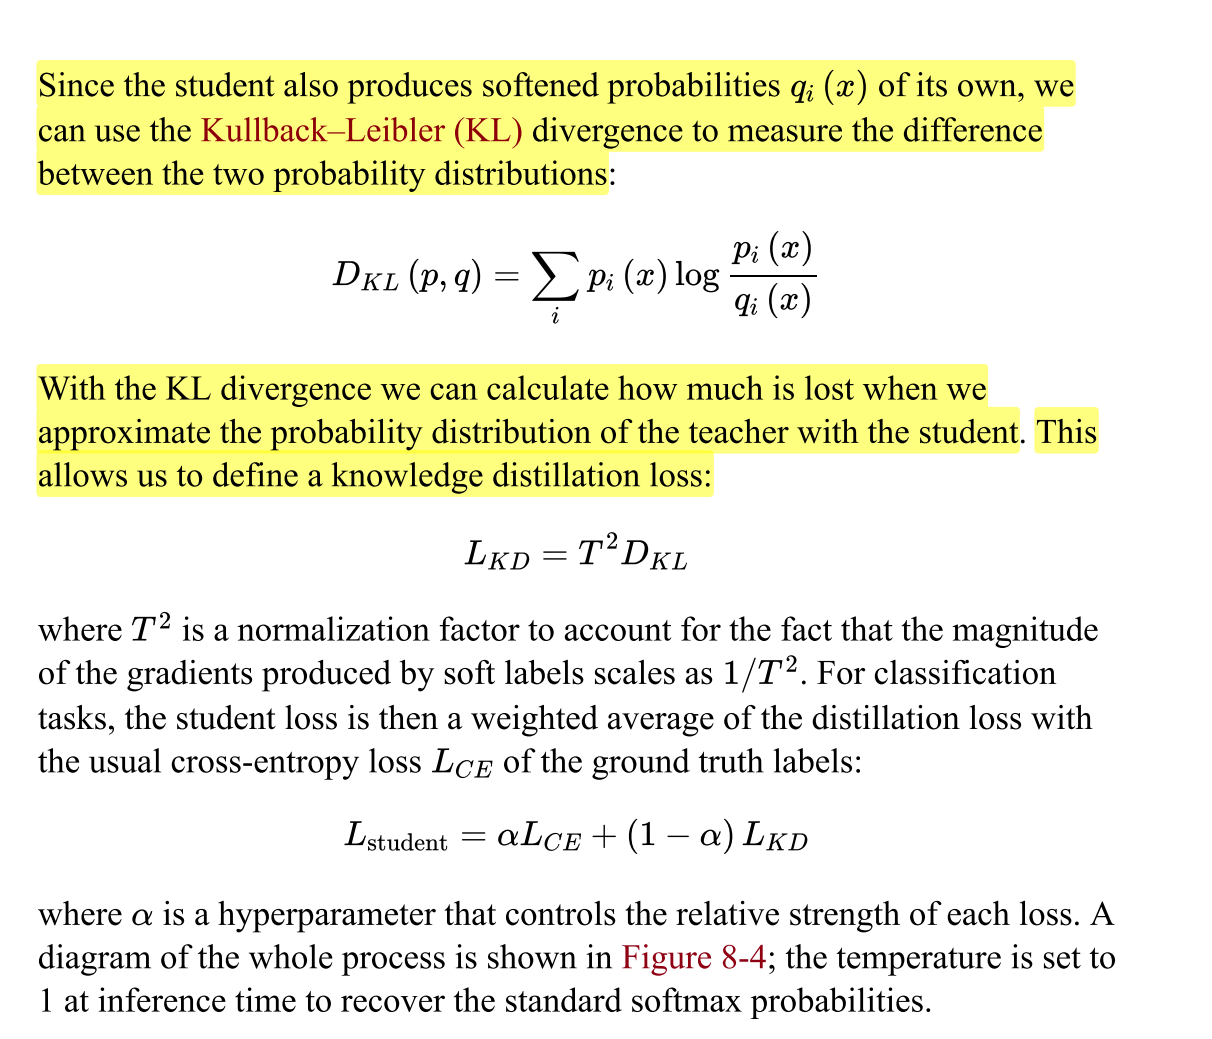

### Knowledge Distillation for Pretraining

### Creating a Knowledge Distillation Trainer

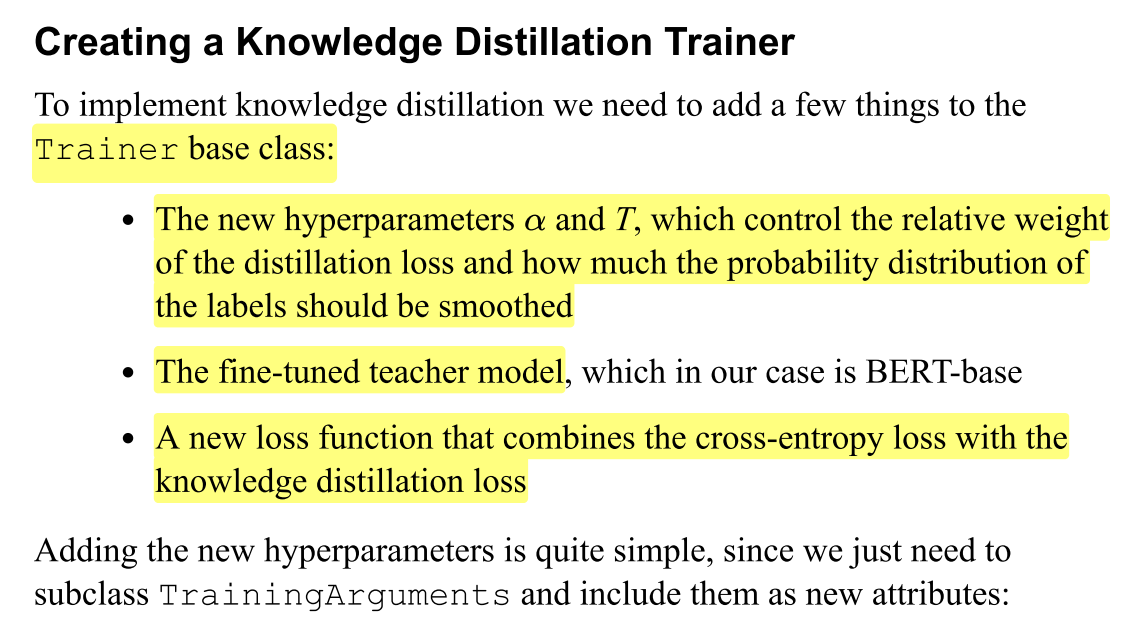

In [ ]:
from transformers import TrainingArguments
# vamos definir os argumentos necessarios para o distillation

class DistillationTrainingArguments(TrainingArguments):
    def __init__(self, *args, alpha=0.5, temperature=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.temperature = temperature

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

class DistillationTrainer(Trainer):
  # precisamos passar o teacher model ao chamar a funçap
    def __init__(self, *args, teacher_model=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model

    def compute_loss(self, model, inputs, return_outputs=False):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        inputs = inputs.to(device)
        # vamos gerar as saidas previstas pelo estudante
        outputs_stu = model(**inputs)
        # Extract cross-entropy loss and logits from student
        loss_ce = outputs_stu.loss
        logits_stu = outputs_stu.logits
        # Extract logits from teacher
        with torch.no_grad():
          # cmom aqui só vamos inferir, nao precisamos armazenar os gradientes
          # estamos no modelo professor
            outputs_tea = self.teacher_model(**inputs)
            logits_tea = outputs_tea.logits

        # Soften probabilities and compute distillation loss

        loss_fct = nn.KLDivLoss(reduction="batchmean")
        #reduction="batchmean" indica que vamos fazer a media dos pesos pr batch
        # lembre-e que Loss Kd = temperatura ao quadrado * DKL
# para achar DKL é aplicad sobre o softmax dos logits do aluno e professor,
# corrigido pela temperatura
#
        loss_kd = self.args.temperature ** 2 * loss_fct(
            F.log_softmax(logits_stu / self.args.temperature, dim=-1),
            F.softmax(logits_tea / self.args.temperature, dim=-1))
        # Return weighted student loss

  # o loss do ESTUDANTE TEM 2 argumentos
  # loss CROSS ETROPY normal do modelo
  # loss resultado da diferença das distribuiçoes entre o modelo e professor
  # o alfa vai regular a importancia que damos à distribuição de probab entre
  #estudante e profesor
        loss = self.args.alpha * loss_ce + (1. - self.args.alpha) * loss_kd
        return (loss, outputs_stu) if return_outputs else loss

### Choosing a Good Student Initialization


we should pick a smaller model for the student to reduce the latency and memory footprint. A good rule of thumb from the literature is that knowledge **distillation works best when the teacher and student are of the same model type.**
---



---



---



---



In [ ]:
#hide_output
# primeiro precisamos tokenizar nossas queries


from transformers import AutoTokenizer

student_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
#vamos puxar o tokenizador
student_tokenizer = AutoTokenizer.from_pretrained(student_ckpt)

# vamos definir a tokenização
def tokenize_text(batch):
    return student_tokenizer(batch["text"], truncation=True)
# vmaos remover a coluna texto porque nao vamos mais precisar dela
#clinc é o nosso dataset definido anteriormente
clinc_enc = clinc.map(tokenize_text, batched=True, remove_columns=["text"])

# nossas labels estao no dataset com o nome intent
# vamos trocar o nome assim o trainer vai entender automaticamente do que se trata
clinc_enc = clinc_enc.rename_column("intent", "labels")

  0%|          | 0/16 [00:00<?, ?ba/s]

  0%|          | 0/4 [00:00<?, ?ba/s]

  0%|          | 0/6 [00:00<?, ?ba/s]

In [ ]:
# vamoslogar no HF
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
# vamos definir a  metrica acuracia
# ja recebemos as prediç~~oes com os logits e as labels
def compute_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy_score.compute(predictions=predictions, references=labels)

In [ ]:
batch_size = 48
# vamos definir os argumentos do treinamento de destilamento
# PRIMEIRO VAMOS USAR ALFA =1 PRA VER COMO SERIA SEM O DESTILAMENTO
finetuned_ckpt = "distilbert-base-uncased-finetuned-clinc"
student_training_args = DistillationTrainingArguments(
    output_dir=finetuned_ckpt, evaluation_strategy = "epoch",
    num_train_epochs=5, learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size, alpha=1, weight_decay=0.01,
    push_to_hub= False,
     report_to=None          )     # evita integrações com Wandb ou Tensorboard)

In [ ]:
#hide
student_training_args.logging_steps = len(clinc_enc['train']) // batch_size
student_training_args.disable_tqdm = False
student_training_args.save_steps = 1e9
student_training_args.log_level = 40

In [ ]:
#hide
%env TOKENIZERS_PARALLELISM=false

env: TOKENIZERS_PARALLELISM=false


In [ ]:
# precisamos separar as correspondencias entre labels e ids de labels
# para enviar ao modelo estudate
id2label = pipe.model.config.id2label
label2id = pipe.model.config.label2id

In [ ]:
from transformers import AutoConfig
# agora vamos passar isso ao nosso modelo estudante
num_labels = intents.num_classes
student_config = (AutoConfig
                  .from_pretrained(student_ckpt, num_labels=num_labels,
                                   id2label=id2label, label2id=label2id))

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# vamos gerar uma funçao para iniciar o modelo aluno
# isso oporque vamos fazer varias iterações, e isso vai ajudar a sempre iniciar
# do zero
def student_init():
    return (AutoModelForSequenceClassification
            .from_pretrained(student_ckpt, config=student_config).to(device))

In [ ]:
#hide_output
# vamos carregar o modelo professor
teacher_ckpt = "transformersbook/bert-base-uncased-finetuned-clinc"
teacher_model = (AutoModelForSequenceClassification
                 .from_pretrained(teacher_ckpt, num_labels=num_labels)
                 .to(device))

In [ ]:
distilbert_trainer = DistillationTrainer(model_init=student_init,
    teacher_model=teacher_model, args=student_training_args,
    train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics, tokenizer=student_tokenizer)

distilbert_trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use thePyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cassio-slima92 (cassio-slima92-governo-de-santa-catarina-brazil) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.578600,0.431730,0.950000
2,0.232900,0.295181,0.955161
3,0.113600,0.254820,0.957419
4,0.074400,0.246698,0.956452
5,0.058300,0.241517,0.956129


TrainOutput(global_step=1590, training_loss=0.21111222505569457, metrics={'train_runtime': 440.5771, 'train_samples_per_second': 173.068, 'train_steps_per_second': 3.609, 'total_flos': 818356364633100.0, 'train_loss': 0.21111222505569457, 'epoch': 5.0})

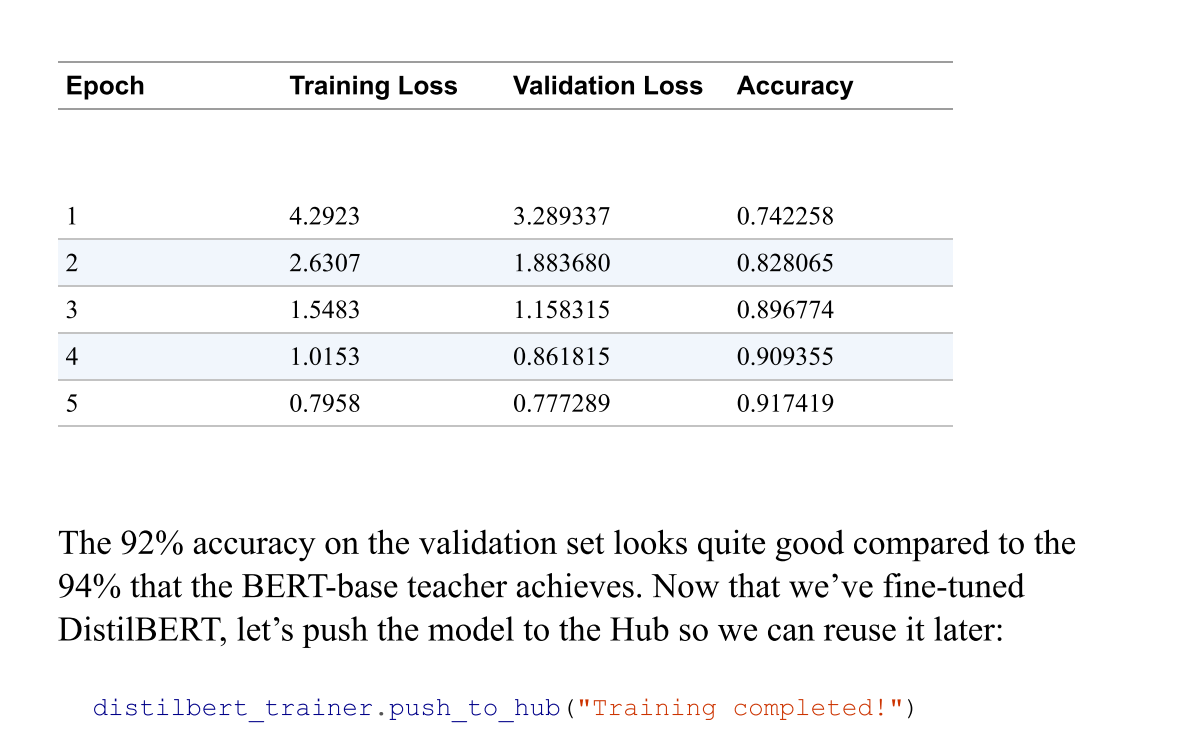

In [ ]:
#hide_output (essa parte acabou ficando inutilizada porque eu desativei o push pro git)
distilbert_trainer.push_to_hub("Training completed!")

AttributeError: 'DistillationTrainer' object has no attribute 'repo'

In [ ]:
#hide_output
finetuned_ckpt = "transformersbook/distilbert-base-uncased-finetuned-clinc"
pipe = pipeline("text-classification", model=finetuned_ckpt)

Downloading:   0%|          | 0.00/8.01k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/256M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/333 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
optim_type = "DistilBERT"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

Model size (MB) - 255.88
Average latency (ms) - 13.45 +\- 0.42
Accuracy on test set - 0.858


AttributeError: 'Legend' object has no attribute 'legendHandles'

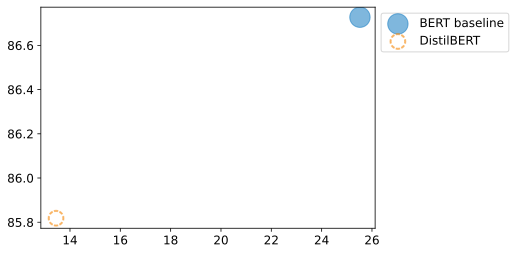

In [ ]:
import pandas as pd
# vamos plotar a acuracia em relação à latencia
def plot_metrics(perf_metrics, current_optim_type):
    df = pd.DataFrame.from_dict(perf_metrics, orient='index')

    for idx in df.index:
        df_opt = df.loc[idx]
        # Add a dashed circle around the current optimization type
        if idx == current_optim_type:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        alpha=0.5, s=df_opt["size_mb"], label=idx,
                        marker='$\u25CC$')
        else:
            plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                        s=df_opt["size_mb"], label=idx, alpha=0.5)

    legend = plt.legend(bbox_to_anchor=(1,1))
    for handle in legend.legendHandles:
        handle.set_sizes([20])

    plt.ylim(80,90)
    # Use the slowest model to define the x-axis range
    xlim = int(perf_metrics["BERT baseline"]["time_avg_ms"] + 3)
    plt.xlim(1, xlim)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Average latency (ms)")
    plt.show()

plot_metrics(perf_metrics, optim_type)
# melhoramos a latencia perdendo apenas 1% de acuracia

# AGORA VARIE O ALFA PARA VER AS ALTERAÇÕES

### Finding Good Hyperparameters with Optuna

To find good values for α and T, we could do a grid search over the 2D parameter space. But a much better alternative is to use Optuna, which is an optimization framework designed for just this type of task. Optuna formulates the search problem in terms of an objective function that is optimized through multiple trial

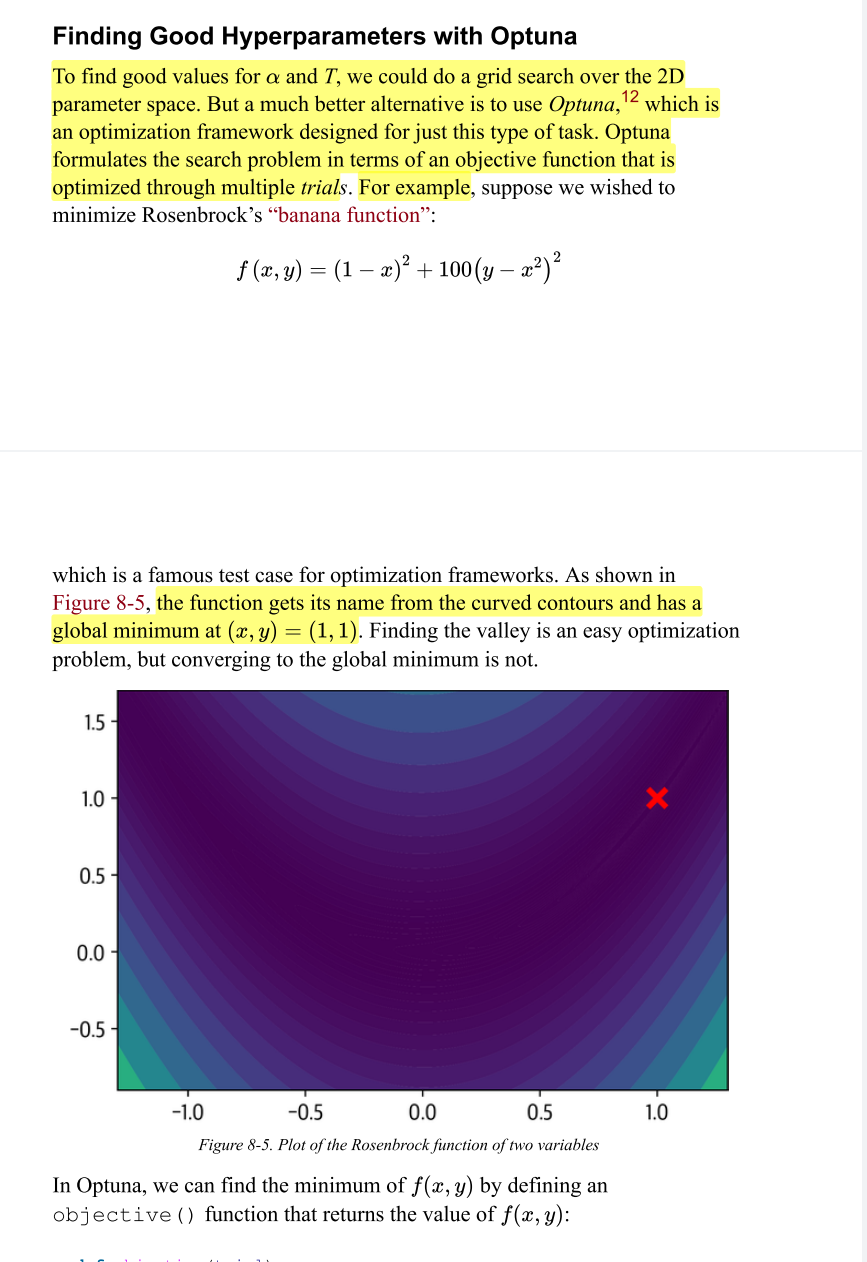

**Antes de otimizarmos nosso codigo, vamos otimizar a função acima para testar ooptuna**

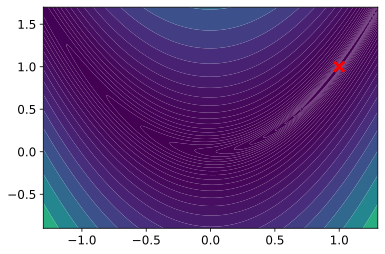

In [ ]:
#hide_input
#id banana-function
#alt A banana plot
#caption Plot of the Rosenbrock function of two variables
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return (1-x)**2+100*(y-x**2)**2

X, Y = np.meshgrid(np.linspace(-2, 2, 250), np.linspace(-1, 3, 250))
Z = f(X,Y)
_, ax = plt.subplots()
ax.plot([1], [1], 'x', mew=3, markersize=10, color="red")
ax.contourf(X, Y, Z, np.logspace(-1, 3, 30), cmap='viridis', extend="both")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.9, 1.7)
plt.show()

In [ ]:
# com o optuna nós encontramos o mínimo da função definindo uma função objetivo
# lembrando que vamos otimizar a função definida
def objective(trial):
  # usamos o sugest_fltoa, mas se necessario tambem temos suggest par int e categorical
    x = trial.suggest_float("x", -2, 2)
    y = trial.suggest_float("y", -2, 2)
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

In [ ]:
#hide_output
import optuna

study = optuna.create_study()
study.optimize(objective, n_trials=1000)

[I 2025-04-26 17:42:30,299] A new study created in memory with name: no-name-7043c8a3-b305-4bd3-9b48-c7485064a302
[I 2025-04-26 17:42:30,301] Trial 0 finished with value: 664.6392971248016 and parameters: {'x': 1.0337431199130669, 'y': -1.5094328776909527}. Best is trial 0 with value: 664.6392971248016.
[I 2025-04-26 17:42:30,303] Trial 1 finished with value: 268.91183690428477 and parameters: {'x': 0.49210009579489933, 'y': -1.3969039208265328}. Best is trial 1 with value: 268.91183690428477.
[I 2025-04-26 17:42:30,304] Trial 2 finished with value: 1927.6492884443073 and parameters: {'x': -1.826677995564916, 'y': -1.0446390374095862}. Best is trial 1 with value: 268.91183690428477.
[I 2025-04-26 17:42:30,305] Trial 3 finished with value: 261.7788282748379 and parameters: {'x': 1.185294078359426, 'y': -0.21292990141420454}. Best is trial 3 with value: 261.7788282748379.
[I 2025-04-26 17:42:30,307] Trial 4 finished with value: 17.67114730823969 and parameters: {'x': -0.21445062899941458

In [ ]:
study.best_params
# veja que estao bem proximos de 1,1 qu é a otimização da banan function
# coletamos os melhores parametros

{'x': 0.9931305736475494, 'y': 0.9862278002402156}

**AGORA VAMOS USAR O OPTUNA PARA O NOSSO PROBLEMA**

In [ ]:
# VAMOS DEFINIR O HORIZONTE DE PARAMETROS PARA OTIMIZARMOS
def hp_space(trial):
    return {"num_train_epochs": trial.suggest_int("num_train_epochs", 5, 10),
        "alpha": trial.suggest_float("alpha", 0, 1),
        "temperature": trial.suggest_int("temperature", 2, 20)}

In [ ]:
#hide_output
# COMO ESTAMOS TRATANDO DE ACURACIA, NOSSO OBJETIVO É MAXIMIZAR
# CUIDADO, SE FOR CUSTO DEVEMOS MINIMIZAR
best_run = distilbert_trainer.hyperparameter_search(
    n_trials=20, direction="maximize", hp_space=hp_space)

[I 2025-04-26 17:42:43,643] A new study created in memory with name: no-name-6d1ff163-9336-422c-bb98-cc33750a0db1
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use thePyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


eval/accuracy,▁▆█▇▇
eval/loss,█▃▁▁▁
eval/runtime,▁▆▅▇█
eval/samples_per_second,█▃▄▂▁
eval/steps_per_second,█▃▄▂▁
train/epoch,▁▁▃▃▄▅▆▆███
train/global_step,▁▁▃▃▄▅▆▆███
train/learning_rate,█▆▅▃▁
train/loss,█▃▂▁▁
train/total_flos,▁
train/train_loss,▁


Epoch,Training Loss,Validation Loss,Accuracy
1,0.026000,0.006028,0.943871
2,0.022200,0.005696,0.946129
3,0.019900,0.005143,0.945161
4,0.018200,0.004695,0.946129
5,0.017300,0.004539,0.949677
6,0.016600,0.004143,0.948065
7,0.015900,0.004200,0.948710
8,0.015500,0.003890,0.948387
9,0.015200,0.003774,0.947097


[I 2025-04-26 17:49:35,126] Trial 0 finished with value: 0.9470967741935484 and parameters: {'num_train_epochs': 9, 'alpha': 0.2919647461861613, 'temperature': 20}. Best is trial 0 with value: 0.9470967741935484.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use thePyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


eval/accuracy,▁▄▃▄█▆▇▆▅
eval/loss,█▇▅▄▃▂▂▁▁
eval/runtime,▃▆▄▅▅▃▅▁█
eval/samples_per_second,▆▃▅▄▄▆▄█▁
eval/steps_per_second,▆▃▅▄▄▆▄█▁
train/epoch,▁▁▂▂▃▃▄▄▄▅▅▅▆▆▇▇███
train/global_step,▁▁▂▂▃▃▄▄▄▅▅▅▆▆▇▇███
train/learning_rate,█▇▆▅▅▄▃▂▁
train/loss,█▆▄▃▂▂▁▁▁
train/total_flos,▁
train/train_loss,▁


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.026000,0.005699,0.944194
2,0.022100,0.005046,0.945806
3,0.019700,0.004051,0.945161
4,0.018200,0.003484,0.947742
5,0.017500,0.003218,0.948387


[I 2025-04-26 18:50:52,136] Trial 18 pruned. 
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use thePyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


eval/accuracy,▁▄▃▇█
eval/loss,█▆▃▂▁
eval/runtime,█▁▆▄▆
eval/samples_per_second,▁█▃▅▃
eval/steps_per_second,▁█▃▅▃
train/epoch,▁▁▃▃▄▅▆▆██
train/global_step,▁▁▃▃▄▅▆▆██
train/learning_rate,█▆▅▃▁
train/loss,█▅▃▂▁
eval/accuracy,0.94839
eval/loss,0.00322


Epoch,Training Loss,Validation Loss,Accuracy
1,0.026500,0.005979,0.944194
2,0.022500,0.005535,0.945484


[I 2025-04-26 18:52:29,436] Trial 19 pruned. 


In [ ]:
print(best_run)
# hyperparameter_search() RETORNA  BEST_RUN
#que contem os valores da funçao objetivos que nesse caso maximizaram a funçao

BestRun(run_id='1', objective=0.9483870967741935,
hyperparameters={'num_train_epochs': 8, 'alpha': 0.6706734389267713,
'temperature': 9})


In [ ]:
#hide_output
# vamos agora criar nosso bert com esses parametros
for k,v in best_run.hyperparameters.items():
    setattr(student_training_args, k, v)

# Define a new repository to store our distilled model
distilled_ckpt = "distilbert-base-uncased-distilled-clinc"
student_training_args.output_dir = distilled_ckpt

# Create a new Trainer with optimal parameters
distil_trainer = DistillationTrainer(model_init=student_init,
    teacher_model=teacher_model, args=student_training_args,
    train_dataset=clinc_enc['train'], eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics, tokenizer=student_tokenizer)

distil_trainer.train();

# aqui nós vemos que conseguimos melhorar a curacia do modelo

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use thePyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.400700,0.300407,0.950645
2,0.181100,0.223456,0.955806
3,0.115200,0.206378,0.957097
4,0.093900,0.202910,0.955806
5,0.083700,0.201239,0.956452
6,0.079600,0.199786,0.957097
7,0.076500,0.199764,0.957742
8,0.074500,0.199077,0.957097


In [ ]:
#hide_output
distil_trainer.push_to_hub("Training complete")

AttributeError: 'DistillationTrainer' object has no attribute 'repo'

### Benchmarking Our Distilled Model
let’s create a pipeline and redo our benchmark to see how we perform on the test set

In [ ]:
distilled_ckpt = "transformersbook/distilbert-base-uncased-distilled-clinc"
pipe = pipeline("text-classification", model=distilled_ckpt)
optim_type = "Distillation"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

Downloading:   0%|          | 0.00/8.01k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/256M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/333 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model size (MB) - 255.88
Average latency (ms) - 13.39 +\- 0.62
Accuracy on test set - 0.868


AttributeError: 'Legend' object has no attribute 'legendHandles'

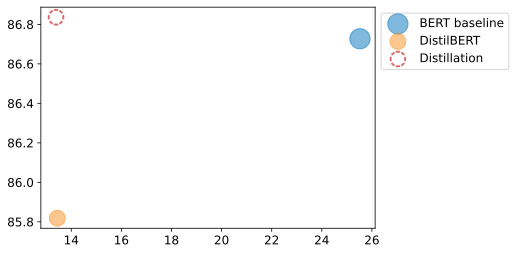

In [ ]:
plot_metrics(perf_metrics, optim_type)

As expected, the model size and latency remain essentially unchanged compared to the DistilBERT benchmark, but the accuracy has improved and even surpassed the performance of the teacher! One way to interpret this surprising result is that the teacher has likely not been fine-tuned as systematically as the student. This is great, but we can actually compress our distilled model even further using a technique known as quantization. That’s the topic of the next section.

## Making Models Faster with Quantization

We’ve now seen that with knowledge distillation we can reduce the computational and memory cost of running inference by transferring the information from a teacher into a smaller student. Quantization takes a different approach; instead of reducing the number of computations, it makes them much more efficient by representing the weights and activations with low-precision data types like 8-bit integer (INT8) instead of the usual 32-bit floating point (FP32). Reducing the number of bits means the resulting model requires less memory storage, and operations like matrix multiplication can be performed much faster with integer arithmetic. Remarkably, these performance gains can be realized with little to no loss in accuracy!

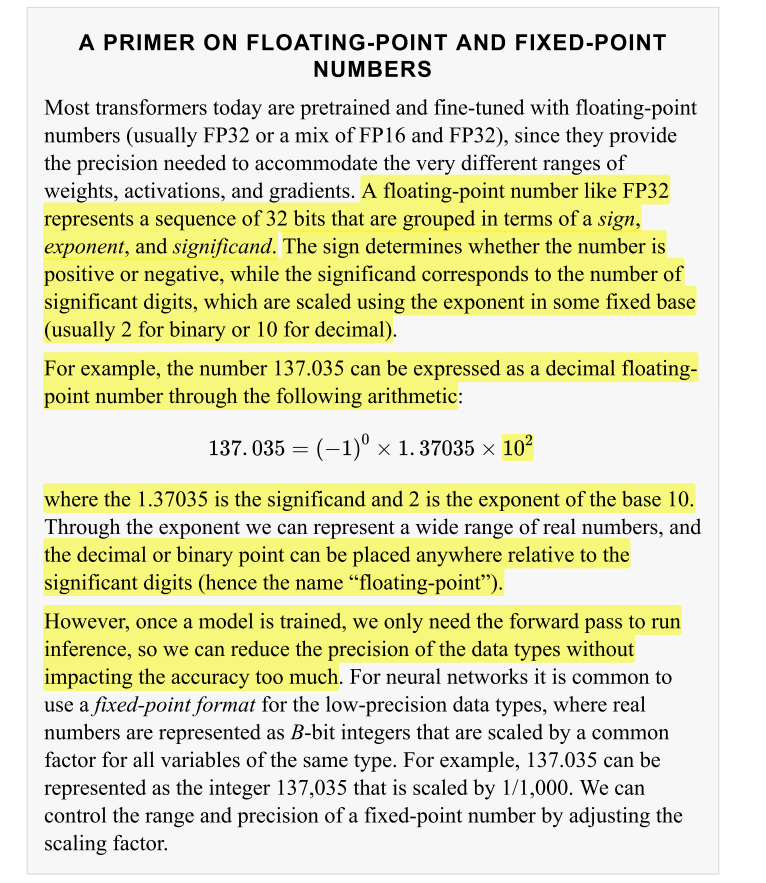

### Sidebar: A Primer on Floating-Point and Fixed-Point Numbers

### End sidebar

<img alt="Mapping floating-point numbers to 8-bit integers" width="800" caption="Quantizing floating-point numbers as unsigned 8-bit integers (courtesy of Manas Sahni)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_fp32-to-int8.png?raw=1" id="fp32toint8"/>

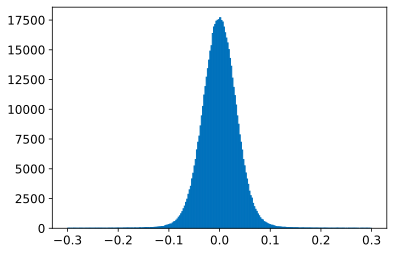

In [ ]:
import matplotlib.pyplot as plt

state_dict = pipe.model.state_dict()
weights = state_dict["distilbert.transformer.layer.0.attention.out_lin.weight"]
plt.hist(weights.flatten().numpy(), bins=250, range=(-0.3,0.3), edgecolor="C0")
plt.show()

In [ ]:
zero_point = 0
scale = (weights.max() - weights.min()) / (127 - (-128))

In [ ]:
(weights / scale + zero_point).clamp(-128, 127).round().char()

tensor([[ -5,  -8,   0,  ...,  -6,  -4,   8],
        [  8,   3,   1,  ...,  -4,   7,   0],
        [ -9,  -6,   5,  ...,   1,   5,  -3],
        ...,
        [  6,   0,  12,  ...,   0,   6,  -1],
        [  0,  -2, -12,  ...,  12,  -7, -13],
        [-13,  -1, -10,  ...,   8,   2,  -2]], dtype=torch.int8)

In [ ]:
from torch import quantize_per_tensor

dtype = torch.qint8
quantized_weights = quantize_per_tensor(weights, scale, zero_point, dtype)
quantized_weights.int_repr()

tensor([[ -5,  -8,   0,  ...,  -6,  -4,   8],
        [  8,   3,   1,  ...,  -4,   7,   0],
        [ -9,  -6,   5,  ...,   1,   5,  -3],
        ...,
        [  6,   0,  12,  ...,   0,   6,  -1],
        [  0,  -2, -12,  ...,  12,  -7, -13],
        [-13,  -1, -10,  ...,   8,   2,  -2]], dtype=torch.int8)

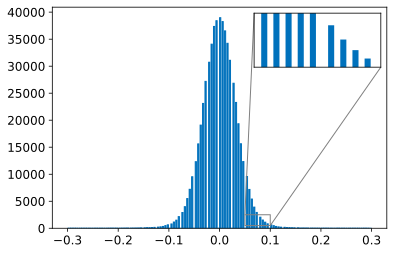

In [ ]:
#hide_input
#id weight-quantization
#alt Effect of quantization on a transformer's weights
#caption Effect of quantization on a transformer's weights
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes,mark_inset

# Create histogram
fig, ax = plt.subplots()
ax.hist(quantized_weights.dequantize().flatten().numpy(),
         bins=250, range=(-0.3,0.3), edgecolor="C0");
# Create zoom inset
axins = zoomed_inset_axes(ax, 5, loc='upper right')
axins.hist(quantized_weights.dequantize().flatten().numpy(),
         bins=250, range=(-0.3,0.3));
x1, x2, y1, y2 = 0.05, 0.1, 500, 2500
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axes.xaxis.set_visible(False)
axins.axes.yaxis.set_visible(False)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.show()

In [ ]:
%%timeit
weights @ weights

1.39 ms ± 156 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
from torch.nn.quantized import QFunctional

q_fn = QFunctional()

In [ ]:
%%timeit
q_fn.mul(quantized_weights, quantized_weights)

86.6 µs ± 44.2 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
import sys

sys.getsizeof(weights.storage()) / sys.getsizeof(quantized_weights.storage())

<ipython-input-59-600687c2638a>:3: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  sys.getsizeof(weights.storage()) / sys.getsizeof(quantized_weights.storage())


3.999715196311114

In [ ]:
#hide_output
# APLICAR A QUANTIZAÇÃO É BEM SIMPLES:
from torch.quantization import quantize_dynamic

model_ckpt = "transformersbook/distilbert-base-uncased-distilled-clinc"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt).to("cpu"))

model_quantized = quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

### Benchmarking Our Quantized Model

In [ ]:
# vamos avaliar as metricas do nosso modelo quantizado
pipe = pipeline("text-classification", model=model_quantized,
                tokenizer=tokenizer)
optim_type = "Distillation + quantization"
pb = PerformanceBenchmark(pipe, clinc["test"], optim_type=optim_type)
perf_metrics.update(pb.run_benchmark())

Model size (MB) - 132.39
Average latency (ms) - 9.91 +\- 0.41
Accuracy on test set - 0.876


AttributeError: 'Legend' object has no attribute 'legendHandles'

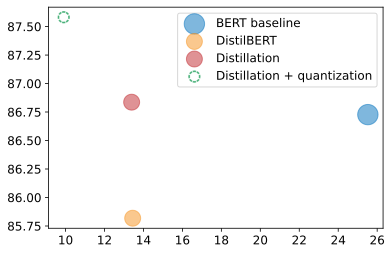

In [ ]:
plot_metrics(perf_metrics, optim_type)

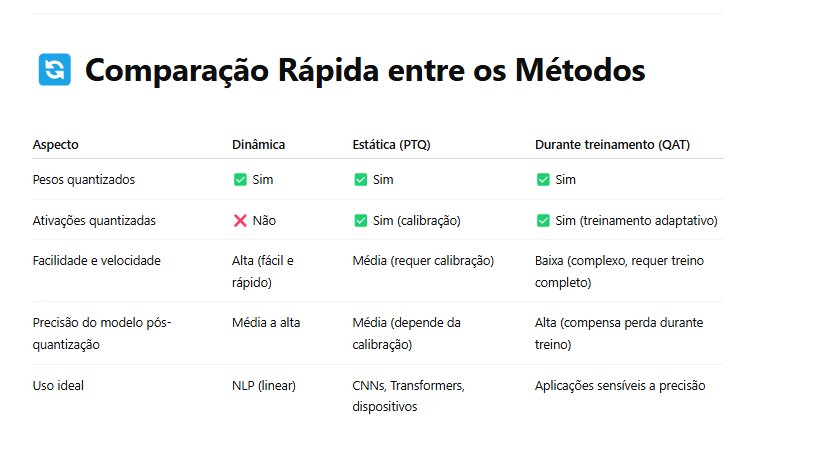

## Optimizing Inference with ONNX and the ONNX Runtime

ONNX is an open standard that defines a common set of operators and a common file format to represent deep learning models in a wide variety of frameworks, including PyTorch and TensorFlow.

When a model is exported to the ONNX format, these operators are used to construct a computational graph (often called an intermediate representation) that represents the flow of data through the neural network.

**For example, a model trained in PyTorch can be exported to ONNX format and then imported in TensorFlow (and vice versa).**

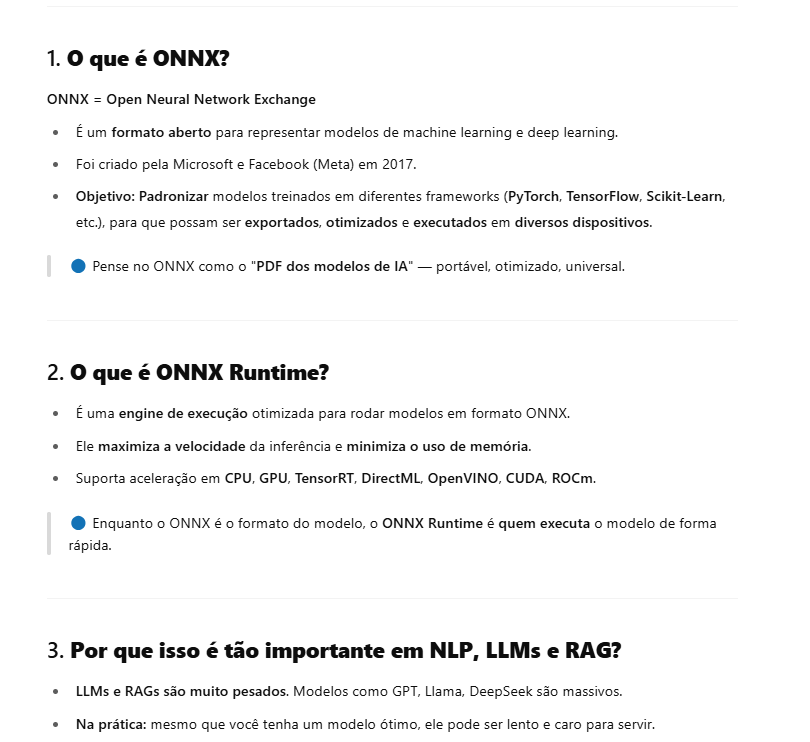

<img alt="Example ONNX graph" width="500" caption="A section of the ONNX graph for BERT-base, visualized in Netron" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_bert-onnx.png?raw=1" id="bert-onnx"/>

<img alt="Architecture of the ONNX and ONNX Runtime ecosystem" width="500" caption="Architecture of the ONNX and ONNX Runtime ecosystem (courtesy of the ONNX Runtime team)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_onnx-ort.png?raw=1" id="onnx-ort"/>

To see ORT in action, the first thing we need to do is convert our distilled model into the ONNX format. The Transformers library has a built-in function called con vert_graph_to_onnx.convert() that simplifies the process by taking the following steps:

1. Initialize the model as a Pipeline.

2. Run placeholder inputs through the pipeline so that ONNX can record the computational graph.

3. Define dynamic axes to handle dynamic sequence lengths.

4. Save the graph with network parameters.

To use this function, we first need to set some OpenMP environment variables for ONNX:

OpenMP is an API designed for developing highly parallelized applications. The OMP_NUM_THREADS environment variable sets the number of threads to use for parallel computations in the ONNX Runtime, while OMP_WAIT_POLICY=ACTIVE specifies that waiting threads should be active (i.e., using CPU processor cycles).

In [ ]:
#hide_output
import os
from psutil import cpu_count

os.environ["OMP_NUM_THREADS"] = f"{cpu_count()}"
os.environ["OMP_WAIT_POLICY"] = "ACTIVE"

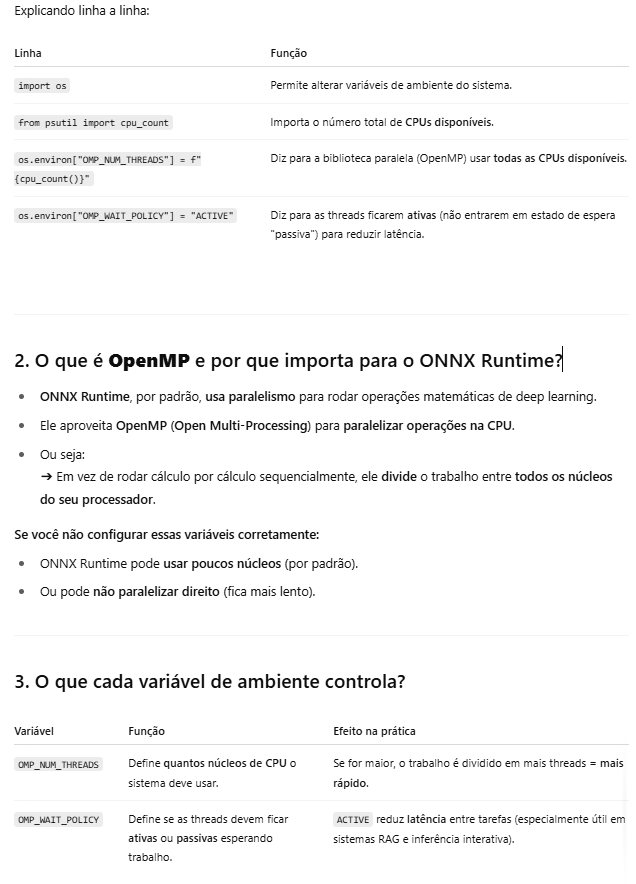

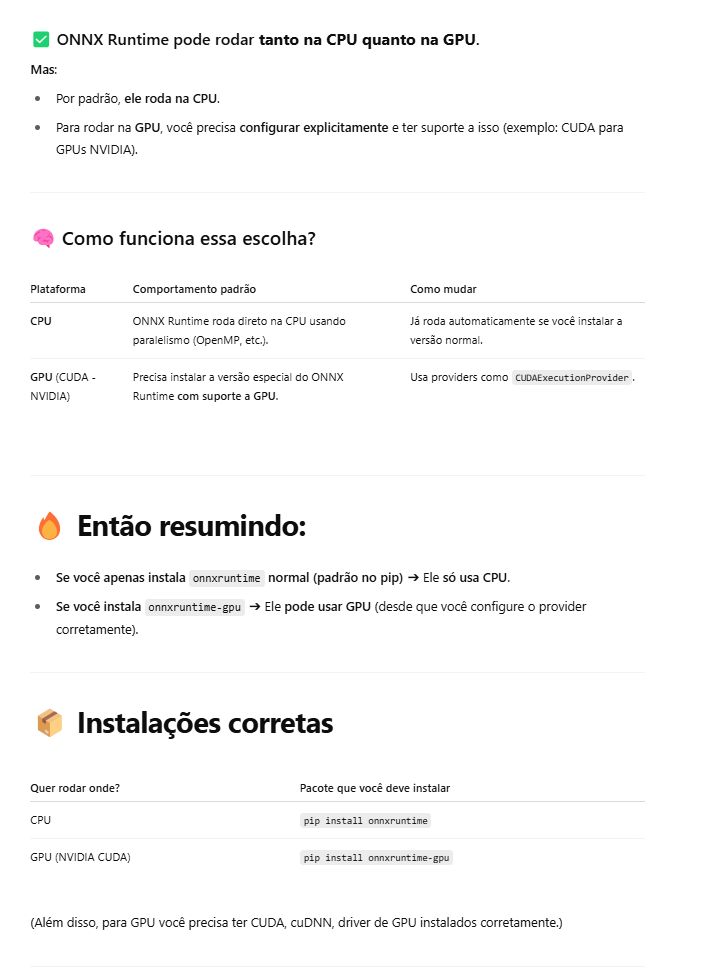

**ONNX não recebe tensores, recebe formatos em numpy e semelhantes**

In [ ]:
#hide_output
from transformers.convert_graph_to_onnx import convert
# vamos converter nosso modelo para o formato onnx
#precisamos informar o tipo do pipeline
model_ckpt = "transformersbook/distilbert-base-uncased-distilled-clinc"
onnx_model_path = Path("onnx/model.onnx")
convert(framework="pt", model=model_ckpt, tokenizer=tokenizer,
        output=onnx_model_path, opset=12, pipeline_name="text-classification")
#ONNX uses operator sets to group together immutable operator specifications,
# so opset=12 corresponds to a specific version of the ONNX library.

ONNX opset version set to: 12
Loading pipeline (model: transformersbook/distilbert-base-uncased-distilled-clinc, tokenizer: PreTrainedTokenizerFast(name_or_path='transformersbook/distilbert-base-uncased-distilled-clinc', vocab_size=30522, model_max_len=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}))
Creating folder onnx
Using framework PyTorch: 2.6.0+cu124
Found input input_ids with shape: {0: 'batch', 1: 'sequence'}
Found input attention_mask with shape: {0: 'batch', 1: 'sequence'}
Found output output_0 with shape: {0: 'batch'}
Ensuring inputs are in correct order
head_mask is not present in the generated input list.
Generated inputs order: ['input_ids', 'attention_mask']


In [ ]:
from onnxruntime import (GraphOptimizationLevel, InferenceSession,
                         SessionOptions)
# AGORA NOSSO MODELO JÁ FOI SALVO E PRECISAMOS CRIAR UMA SESSÃO DE INFERENCIA
#PARA ALIMENTAR O MODELO COM OS INPUTS

#provider → backend onde o modelo será executado.
#Default = "CPUExecutionProvider"
 #(mas poderia ser "CUDAExecutionProvider" para GPU).
def create_model_for_provider(model_path, provider="CPUExecutionProvider"):
  #Cria um objeto SessionOptions, que permite configurar como o ONNX Runtime vai rodar o modelo
    options = SessionOptions()
  #Define o número de threads internas (intra-op parallelism) como 1. (apenas teste)
    options.intra_op_num_threads = 1
  #Diz para o ONNX Runtime aplicar todas as otimizações possíveis no grafo computacional do modelo.
  #ORT_ENABLE_ALL é o nivel maximo de otimização
    options.graph_optimization_level = GraphOptimizationLevel.ORT_ENABLE_ALL

    #vamos criar a sessao de inferencia com as options que acabamos de definir
    session = InferenceSession(str(model_path), options, providers=[provider])
    session.disable_fallback()
    # fallback disable Impede que o ONNX Runtime "caia para outro executor" caso o provider principal falhe.
    #Se você escolheu "CUDAExecutionProvider" mas sua GPU falhar ou faltar suporte, o ONNX Runtime automaticamente tentaria rodar na CPU.
    #ele desabilitado gerara uma falha geral se a CPU falahar (no nosso exemplo)
    return session

    #Por fim, a função retorna a session pronta para ser usada para inferência!

In [ ]:
onnx_model = create_model_for_provider(onnx_model_path)

#Now when we call onnx_model.run(), we can get the class logits from the ONNX model

In [ ]:
# os inputs do ONNX  contém apenas os input_ids e as attention masks
# por isso precisamos dropar a coluna labels
inputs = clinc_enc["test"][:1]
del inputs["labels"]
# ao gerar o run vamos coletar os logits
logits_onnx = onnx_model.run(None, inputs)[0]
logits_onnx.shape

RuntimeError: Failed to find input with name: token_type_ids in the model input def list

In [ ]:
np.argmax(logits_onnx)
# aqui nos vamos coletar a previsao do nosso modelo onnx

In [ ]:
clinc_enc["test"][0]["labels"]
# aqui vamos comparar o resultado do nosso logit com a ground truth do exemplo

61

In [ ]:
from scipy.special import softmax
# O modelo Onnx não é compatível com text classification,
#por isso precisamos criar um pipeline para ajusta-lo

#vamos criar a classe que vai simular a inferecia do modelo ONNX
class OnnxPipeline:
    def __init__(self, model, tokenizer):#modelo é o ONNX
        self.model = model
        self.tokenizer = tokenizer

#Este método permite que a instância da classe seja chamada como uma função.
    def __call__(self, query):
      # tokeniza e recebe os tensores em pytorch
        model_inputs = self.tokenizer(query, return_tensors="pt")
        # COMO O ONNX NAO TRABALHA COM TENSORES:
        # transforma os tensores em arrays numpy
        #move o tensor para cpu
        #Remove o grafo de computação do PyTorch (detach())
        #converte para numpy
        #faz isso para cada item do dicionário model_inputs (ex.: input_ids, attention_mask, etc.).
        inputs_onnx = {k: v.cpu().detach().numpy()
                       for k, v in model_inputs.items()}

        # pega a primeira saida model.run(None, inputs_onnx)[0]
        #ESSA SAIDA GERALMNETE É A CLASSIFICAÇAO
        #COMO O BATCH SIZE = 1 PEGAMOS APENAS A PRIMEIRA OCORRENCIA [0,:]
        # ISSO PRECISA SER FEITO PORQUE GERALMENTE É UMA MATRIZ 2D QUE SAI DALI (BATCH SIZE , NUM CLASS)
        logits = self.model.run(None, inputs_onnx)[0][0, :]

        # converte os logits em probabilidade
        probs = softmax(logits)

        #Usa np.argmax(probs) para pegar o índice da maior probabilidade (classe predita)
        #.items() transforma de array numpy para python puro
        pred_idx = np.argmax(probs).item()
        return [{"label": intents.int2str(pred_idx), "score": probs[pred_idx]}]

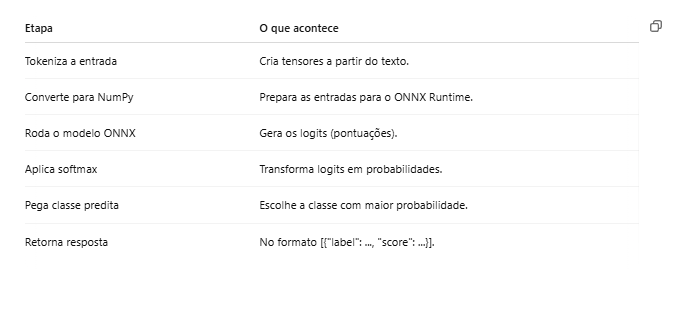

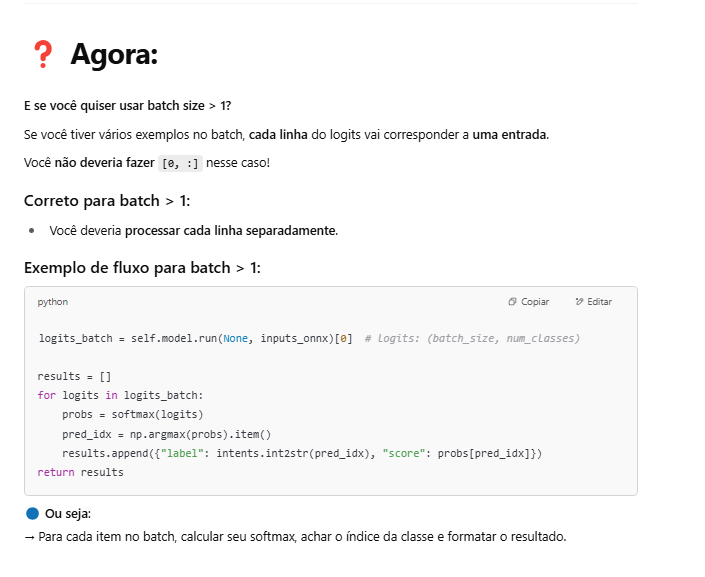

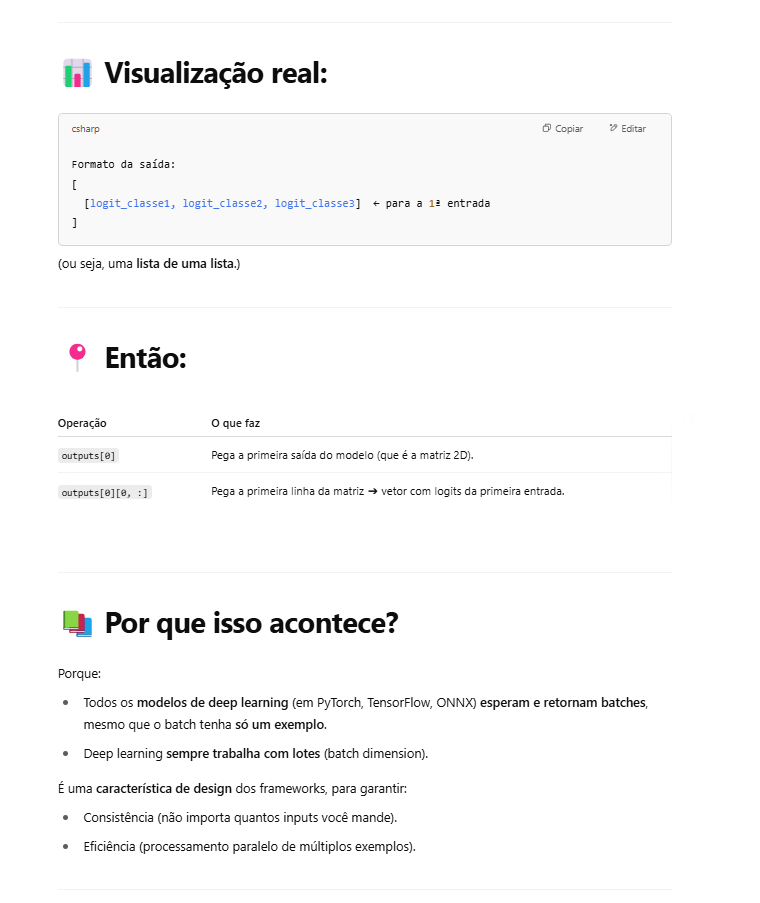

In [ ]:
pipe = OnnxPipeline(onnx_model, tokenizer)
pipe(query)
# vamos testar a saida

[{'label': 'car_rental', 'score': np.float32(0.7848335)}]

**AVALIANDO O MODELO ONNX**

Great, our pipeline works as expected. The next step is to create a performance benchmark for ONNX models. Here we can build on the work we did with the Per formanceBenchmark class by simply overriding the compute_size() method and leaving the compute_accuracy() and time_pipeline() methods intact. The reason we need to override the compute_size() method is that we cannot rely on the state_dict and torch.save() to measure a model’s size, since onnx_model is technically an ONNX InferenceSession object that doesn’t have access to the attributes of PyTorch’s nn.Module. In any case, the resulting logic is simple and can be implemented as follows:

In [ ]:
# vamos criar um benchmark de performance para nosso modelo onnx
# VAMOS alterar apenas o compute size, porque ele levava em consideração tensores do pytorch
class OnnxPerformanceBenchmark(PerformanceBenchmark):
    def __init__(self, *args, model_path, **kwargs):
        super().__init__(*args, **kwargs)
        self.model_path = model_path

    def compute_size(self):
        size_mb = Path(self.model_path).stat().st_size / (1024 * 1024)
        print(f"Model size (MB) - {size_mb:.2f}")
        return {"size_mb": size_mb}

In [ ]:
optim_type = "Distillation + ORT"
pb = OnnxPerformanceBenchmark(pipe, clinc["test"], optim_type,
                              model_path="onnx/model.onnx")
perf_metrics.update(pb.run_benchmark())

NameError: name 'OnnxPerformanceBenchmark' is not defined

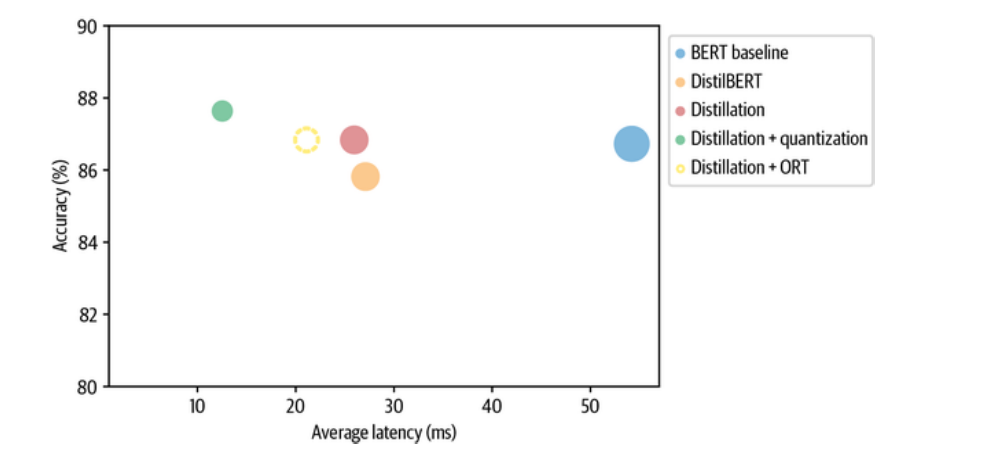

In [ ]:
plot_metrics(perf_metrics, optim_type)
#colei a imagem acima para ver a comparação

**VAMOS ADICIONAR QUANTIZAÇÃO AO NOSSO ONNX PARA VER SE CONSEGUIMOS MELHORAR**

In [ ]:
#ORT offers three ways to quantize a model: dynamic, static, and quantization-aware training
# vamos aplicar a dinamica
from onnxruntime.quantization import quantize_dynamic, QuantType

model_input = "onnx/model.onnx"
model_output = "onnx/model.quant.onnx"
quantize_dynamic(model_input, model_output, weight_type=QuantType.QInt8)

In [ ]:
# com nosso modelo quantizado, vamos agora aplicar os benchmarks
onnx_quantized_model = create_model_for_provider(model_output)
pipe = OnnxPipeline(onnx_quantized_model, tokenizer)
optim_type = "Distillation + ORT (quantized)"
pb = OnnxPerformanceBenchmark(pipe, clinc["test"], optim_type,
                              model_path=model_output)
perf_metrics.update(pb.run_benchmark())

In [ ]:
plot_metrics(perf_metrics, optim_type)

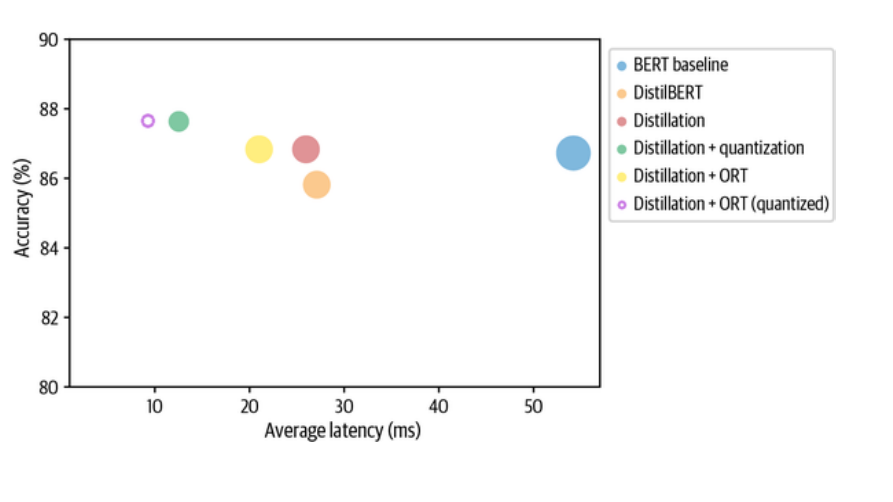

## Making Models Sparser with Weight Pruning

### Sparsity in Deep Neural Networks

<img alt="Network Pruning" width="500" caption="Weights and neurons before and after pruning (courtesy of Song Han)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_network-pruning.png?raw=1" id="network-pruning"/>

### Weight Pruning Methods
So far we’ve seen that knowledge distillation and weight quantization are quite effective at producing faster models for inference, but in some cases you might also have strong constraints on the memory footprint of your model. For example, if our product manager suddenly decides that our text assistant needs to be deployed on a mobile device, then we’ll need our intent classifier to take up as little storage space as possible. To round out our survey of compression methods, let’s take a look at how we can shrink the number of parameters in our model by identifying and removing the least important weights in the network.







#### Magnitude pruning

As shown in Figure 8-10, the main idea behind pruning is to gradually remove weight connections (and potentially neurons) during training such that the model becomes progressively sparser. The resulting pruned model has a smaller number of nonzero parameters, which can then be stored in a compact sparse matrix format. Pruning can be also combined with quantization to obtain further compression.

magnitude puning é um dos metodos mais famosos de pruning

As the name suggests, magnitude pruning calculates the scores according to the magnitude of the weights S = (∣ Wij ∣)1≤j,j≤n and then derives the masks from M= Topk (S). In the literature it is common to apply magnitude pruning in an iterative fashion by first training the model to learn which connections are important and pruning the weights of least importance. The sparse model is the

**One problem with magnitude pruning is that it is really designed for pure supervised learning, where the importance of each weight is directly related to the task at hand. By contrast, in transfer learning the importance of the weights is primarily determined by the pretraining phase, so magnitude pruning can remove connections that are important for the fine-tuning task. Recently, an adaptive approach called movement pruning has been proposed by Hugging Face researchers—let’s take a look.
20**

In [ ]:
#hide_input
#id sparsity-scheduler
#alt Sparsity scheduler
#caption The cubic sparsity scheduler used for pruning
import numpy as np
import matplotlib.pyplot as plt

def _sparsity(t, t_0=0, dt=1, s_i=0, s_f=0.9, N=100):
    return s_f + (s_i - s_f) * (1 - (t - t_0) / (N * dt))**3

steps = np.linspace(0,100,100)
values = [_sparsity(t) for t in steps]

fig, ax = plt.subplots()
ax.plot(steps, values)
ax.set_ylim(0,1)
ax.set_xlim(0,100)
ax.set_xlabel("Pruning step")
ax.set_ylabel("Sparsity")
plt.grid(linestyle="dashed")
plt.show()

#### Movement pruning

The basic idea behind movement pruning is to gradually remove weights during fine-tuning such that the model becomes progressively sparser. The key novelty is that both the weights and the scores are learned during finetuning. So, instead of being derived directly from the weights (like with magnitude pruning), the scores in movement pruning are arbitrary and are learned through gradient descent like any other neural network parameter. This implies that in the backward pass, we also track the gradient of the loss L with respect to the scores Sij.

The intuition behind movement pruning is that the weights that are “moving” the most from zero are the most important ones to keep. In other words, the positive weights increase during fine-tuning (and vice versa for the negative weights), which is equivalent to saying that the scores increase as the weights move away from zero. As shown in Figure 8-12, this behavior differs from magnitude pruning, which selects as the most important weights those that are furthest from zero

<img alt="Magnitude vs Movement Pruning" width="700" caption="Comparison of weights removed (in gray) during magnitude pruning (left) and movement pruning (right)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_magnitude-vs-movement.png?raw=1" id="magnitude-vs-movement"/>

acima, a esquerda temos os pesos removidos no magnitude pruning e a direita no movement pruning

<img alt="Pruning Distributions" width="500" caption="Distribution of remaining weights for magnitude pruning (MaP) and movement pruning (MvP)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_pruning-dists.png?raw=1" id="pruning-dists"/>

These differences between the two pruning methods are also evident in the distribution of the remaining weights. As shown in Figure 8-13, magnitude pruning produces two clusters of weights, while movement pruning produces a smoother distribution.


## Conclusion